# Testando um modelo simples de aprendizado de um Datase aleatório

## Imports

In [6]:
import IPython.display as ipd
import json
import numpy as np
import matplotlib.pyplot as plt
import random
import soundfile as sf
import pandas as pd

from fm_synth import FMSynth, SAMPLE_RATE


## Gerando um dataset aleatório

### Rodando aleatoriamente e salvando o resultado

In [7]:
duracao_amostras = 4
tamanho_dataset = 5000
precisao_decimal = 3
base_path = 'dataset_big2'

## Lendo o dataset no formato pandas

### Lendo as variáveis de entrada

In [8]:
samples = []
for i in range(tamanho_dataset):
    signal = sf.read(f"{base_path}/sample_{i+1}.wav")
    samples.append(signal)

samples = pd.DataFrame(samples)

In [9]:
samples = samples.drop(columns=[1])
samples.head()

,0
0,"[0.0, 0.0, 9.1552734375e-05, 0.000213623046875..."
1,"[0.0, 0.0, 3.0517578125e-05, 9.1552734375e-05,..."
2,"[0.0, 0.0, 0.0, 0.0, 3.0517578125e-05, 6.10351..."
3,"[0.0, 0.0, 3.0517578125e-05, 6.103515625e-05, ..."
4,"[0.0, 0.000579833984375, 0.00030517578125, -0...."


### Lendo o alvo

In [10]:
with open(f"{base_path}/parameters.json", "r") as f:
    target = f.read()

target = json.loads(target)
target = target[:tamanho_dataset]

target = pd.DataFrame(target)
target.head()

,id,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,1,76.024,0.969,0.893,1.602,0.989,0.689,0.000,0.937,0.437,...,2.902,0.000,0.945,0.567,1.153,0.465,0.067,0.111,0.574,0.435
1,2,113.271,0.610,0.400,2.289,0.928,7.379,0.000,0.886,1.474,...,0.193,0.000,0.418,1.025,0.000,0.591,0.195,0.318,0.571,0.455
2,3,65.536,0.773,5.925,5.046,0.529,6.429,0.000,0.874,0.903,...,0.128,4.059,0.656,2.731,0.000,0.685,0.447,0.537,0.474,0.485
3,4,168.892,0.887,1.672,0.000,0.564,1.011,7.851,0.406,2.599,...,0.435,0.000,0.889,0.306,6.342,0.574,0.373,0.316,0.327,0.511
4,5,3663.266,0.893,0.178,0.000,0.515,0.178,0.000,0.916,0.205,...,0.339,0.675,0.648,0.249,0.000,0.445,0.090,0.300,0.507,0.527


In [11]:
# Imprimindo o nome das colunas
print(target.columns)

Index(['id', 'frequencia_base', 'amplitude1', 'frequency1', 'beta2',
       'amplitude2', 'frequency2', 'beta3', 'amplitude3', 'frequency3',
       'beta4', 'amplitude4', 'frequency4', 'beta5', 'amplitude5',
       'frequency5', 'beta_carrier', 'amplitude_carrier', 'attack', 'decay',
       'sustain', 'release'],
      dtype='object')


In [12]:
target = target.drop(columns=["id"])
target.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,76.024,0.969,0.893,1.602,0.989,0.689,0.000,0.937,0.437,0.440,...,2.902,0.000,0.945,0.567,1.153,0.465,0.067,0.111,0.574,0.435
1,113.271,0.610,0.400,2.289,0.928,7.379,0.000,0.886,1.474,0.000,...,0.193,0.000,0.418,1.025,0.000,0.591,0.195,0.318,0.571,0.455
2,65.536,0.773,5.925,5.046,0.529,6.429,0.000,0.874,0.903,4.246,...,0.128,4.059,0.656,2.731,0.000,0.685,0.447,0.537,0.474,0.485
3,168.892,0.887,1.672,0.000,0.564,1.011,7.851,0.406,2.599,1.714,...,0.435,0.000,0.889,0.306,6.342,0.574,0.373,0.316,0.327,0.511
4,3663.266,0.893,0.178,0.000,0.515,0.178,0.000,0.916,0.205,1.695,...,0.339,0.675,0.648,0.249,0.000,0.445,0.090,0.300,0.507,0.527


### Juntando alvo e features

In [13]:
ds = pd.concat([samples, target], axis=1)
ds.head()

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,"[0.0, 0.0, 9.1552734375e-05, 0.000213623046875...",76.024,0.969,0.893,1.602,0.989,0.689,0.000,0.937,0.437,...,2.902,0.000,0.945,0.567,1.153,0.465,0.067,0.111,0.574,0.435
1,"[0.0, 0.0, 3.0517578125e-05, 9.1552734375e-05,...",113.271,0.610,0.400,2.289,0.928,7.379,0.000,0.886,1.474,...,0.193,0.000,0.418,1.025,0.000,0.591,0.195,0.318,0.571,0.455
2,"[0.0, 0.0, 0.0, 0.0, 3.0517578125e-05, 6.10351...",65.536,0.773,5.925,5.046,0.529,6.429,0.000,0.874,0.903,...,0.128,4.059,0.656,2.731,0.000,0.685,0.447,0.537,0.474,0.485
3,"[0.0, 0.0, 3.0517578125e-05, 6.103515625e-05, ...",168.892,0.887,1.672,0.000,0.564,1.011,7.851,0.406,2.599,...,0.435,0.000,0.889,0.306,6.342,0.574,0.373,0.316,0.327,0.511
4,"[0.0, 0.000579833984375, 0.00030517578125, -0....",3663.266,0.893,0.178,0.000,0.515,0.178,0.000,0.916,0.205,...,0.339,0.675,0.648,0.249,0.000,0.445,0.090,0.300,0.507,0.527


In [14]:
ds.shape

(5000, 22)

## Separando treino e teste

In [15]:
train = ds.sample(frac=0.75, random_state=0)
test = ds.drop(train.index)

In [16]:
train.head(5)

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
398,"[0.0, 0.0, 0.0, 3.0517578125e-05, 3.0517578125...",48.359,0.932,3.609,2.490,0.868,4.264,0.959,0.499,0.181,...,0.225,0.224,0.891,1.203,3.920,0.923,0.310,0.208,0.895,0.617
3833,"[0.0, 9.1552734375e-05, 0.000457763671875, 0.0...",582.414,0.647,0.166,1.301,0.532,1.423,0.000,0.573,1.744,...,3.424,3.442,0.661,0.131,0.000,0.950,0.103,0.325,0.129,0.727
4836,"[0.0, 0.0, 3.0517578125e-05, 9.1552734375e-05,...",45.601,0.500,7.010,0.000,0.422,0.249,0.000,0.629,0.343,...,0.317,4.043,0.910,1.943,4.544,0.877,0.085,0.404,0.372,0.318
4572,"[-3.0517578125e-05, 0.00042724609375, -0.00015...",4205.717,0.609,0.140,0.000,0.430,0.351,0.788,0.690,0.236,...,0.289,0.000,0.719,0.384,0.000,0.764,0.120,0.134,0.127,0.093
636,"[0.0, 0.0, 6.103515625e-05, 0.00018310546875, ...",359.852,0.504,3.781,0.805,0.585,3.237,2.062,0.813,0.294,...,7.944,1.858,0.867,0.146,2.417,0.490,0.374,0.502,0.314,0.532


In [17]:
x = pd.DataFrame(train[0])
x.head()

,0
398,"[0.0, 0.0, 0.0, 3.0517578125e-05, 3.0517578125..."
3833,"[0.0, 9.1552734375e-05, 0.000457763671875, 0.0..."
4836,"[0.0, 0.0, 3.0517578125e-05, 9.1552734375e-05,..."
4572,"[-3.0517578125e-05, 0.00042724609375, -0.00015..."
636,"[0.0, 0.0, 6.103515625e-05, 0.00018310546875, ..."


In [18]:
x = np.array(x[0].values.tolist())
x[0]

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
       -2.13623047e-04, -1.52587891e-04, -6.10351562e-05])

In [19]:
len(x[0])

64000

In [20]:
y = train.drop(columns=[0])
y.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
398,48.359,0.932,3.609,2.490,0.868,4.264,0.959,0.499,0.181,0.000,...,0.225,0.224,0.891,1.203,3.920,0.923,0.310,0.208,0.895,0.617
3833,582.414,0.647,0.166,1.301,0.532,1.423,0.000,0.573,1.744,0.000,...,3.424,3.442,0.661,0.131,0.000,0.950,0.103,0.325,0.129,0.727
4836,45.601,0.500,7.010,0.000,0.422,0.249,0.000,0.629,0.343,0.425,...,0.317,4.043,0.910,1.943,4.544,0.877,0.085,0.404,0.372,0.318
4572,4205.717,0.609,0.140,0.000,0.430,0.351,0.788,0.690,0.236,0.000,...,0.289,0.000,0.719,0.384,0.000,0.764,0.120,0.134,0.127,0.093
636,359.852,0.504,3.781,0.805,0.585,3.237,2.062,0.813,0.294,0.000,...,7.944,1.858,0.867,0.146,2.417,0.490,0.374,0.502,0.314,0.532


In [21]:
from sklearn.preprocessing import StandardScaler
scaler_y = StandardScaler()
y_train_norm = scaler_y.fit_transform(y)
print(y_train_norm)

[[-0.70088965  1.46726592  1.30534499 ... -0.61305685  1.70329858
   0.87496966]
 [-0.27881814 -0.18509365 -0.69969395 ...  0.08781003 -1.6057583
   1.3860204 ]
 [-0.70306934 -1.03736332  3.28592513 ...  0.56104494 -0.55601832
  -0.51415917]
 ...
 [ 0.22397295 -0.20248691 -0.49412359 ...  0.20761634  1.47002303
  -1.25285978]
 [ 0.65332484 -0.74747568 -0.66417046 ... -1.47566224  1.62122015
  -0.62566115]
 [ 1.49637723 -0.68949815 -0.72240569 ...  1.59736947  1.25402715
   1.03757672]]


### Redimensionando a entrada

In [22]:
print(x.shape)
x = x.reshape((x.shape[0], x.shape[1], 1))
print(x.shape)

print(x[0])

# frame_length = 2048

# dataset = []
# for sample in x:
#   length = sample.shape[0]
#   num_frames = int(length / frame_length)
#   amostras_uteis = num_frames * frame_length
#   sample_cutted = sample[:amostras_uteis]
#   sample_cutted = sample_cutted.reshape(num_frames, frame_length)
#   dataset.append(sample_cutted)

# x = np.array(dataset)
# print(x.shape)
# x[0:5]

(3750, 64000)
(3750, 64000, 1)
[[ 0.00000000e+00]
 [ 0.00000000e+00]
 [ 0.00000000e+00]
 ...
 [-2.13623047e-04]
 [-1.52587891e-04]
 [-6.10351562e-05]]


## Construindo o modelo

In [23]:
from keras.layers import TimeDistributed, Dense, Input, Lambda, BatchNormalization, Concatenate, Conv1D, ZeroPadding1D, Flatten, Dropout, MaxPooling1D
from keras.models import Model
from tensorflow.keras.utils import plot_model
from keras.callbacks import EarlyStopping
import tensorflow as tf

2025-09-16 21:42:51.251918: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-16 21:42:51.569643: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758069771.679810   27180 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758069771.708683   27180 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758069771.965724   27180 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [24]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [25]:
# Configurando para não alocar diretamente toda a memória da GPU (alocar conforme necessário)
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)  # Aloca memória conforme necessário
    except RuntimeError as e:
        print(e)

I0000 00:00:1758069774.609182   27180 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2756 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5
/home/sergio/@pessoal/fmsynth/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


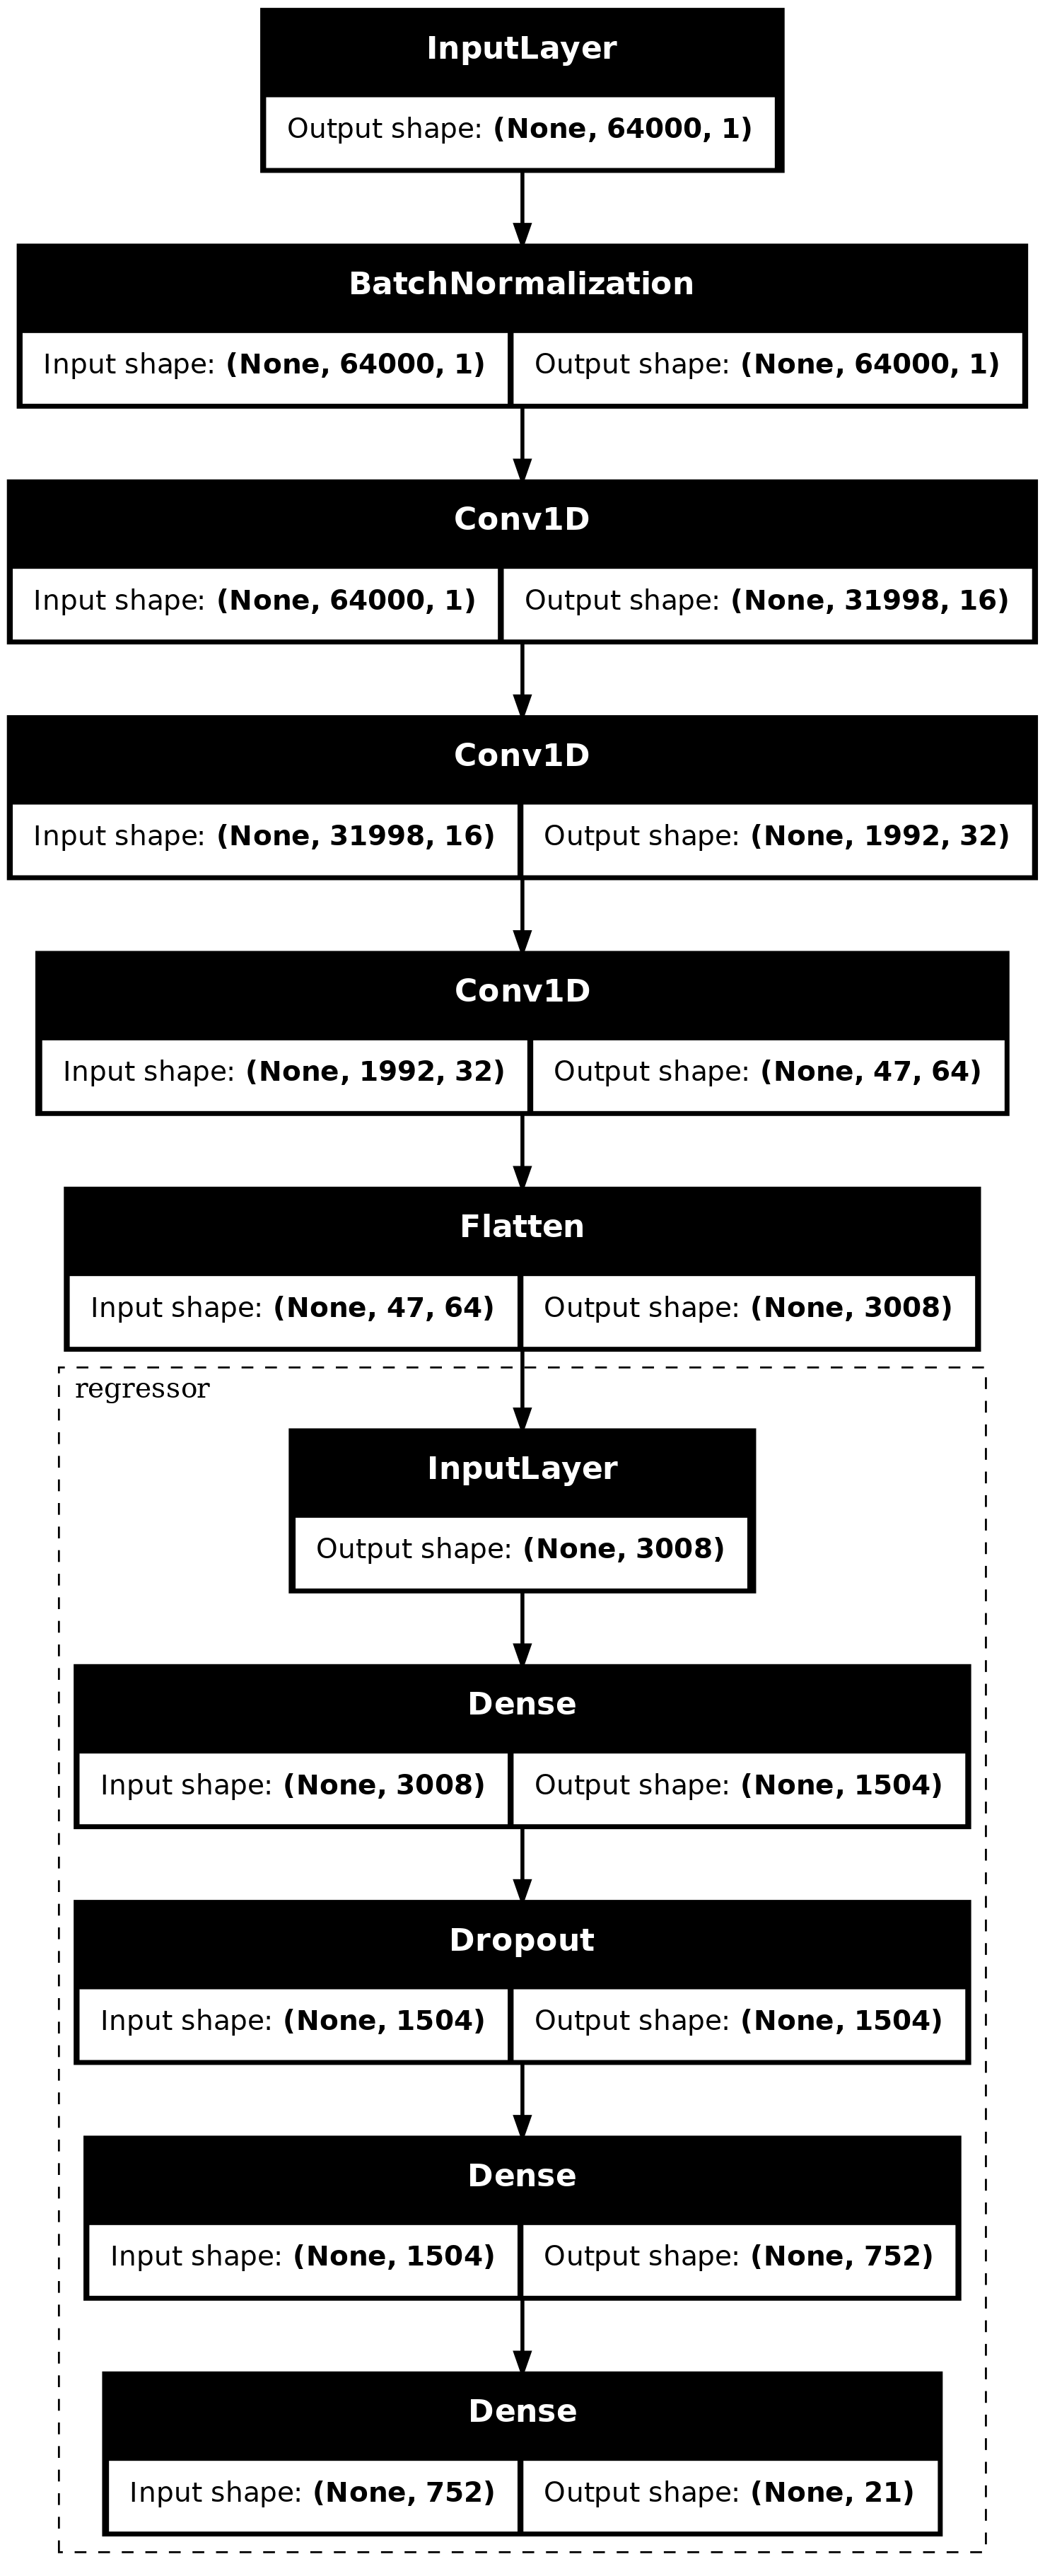

In [26]:
def regressor(input_dims, output_dims, activation, bias):
  input_layer = Input(shape=[input_dims])

  x_0 = Dense(int(input_dims/2), activation=activation, use_bias=bias, kernel_regularizer="l2")(input_layer)
  x_0 = Dropout(0.2)(x_0)
  x_2 = Dense(int(input_dims/4), activation=activation, use_bias=bias)(x_0)
  saidas = Dense(output_dims, activation=None, name='regressor_saidas', use_bias=bias)(x_2)

  return Model(input_layer, saidas, name="regressor")

def build_models(input_len, input_dims, output_dims, activation, bias):
  
  # Camadas de entrada
  input_layer = Input(shape=(input_len, input_dims))

  x_n = BatchNormalization()(input_layer)

  # Features 1
  extrator1 = Conv1D(
    filters=16,
    kernel_size=5,
    strides=2,
    activation='relu',
    input_shape=(input_len, 1),
    kernel_regularizer="l2",
    use_bias=True,
  )
  # pooling1 = MaxPooling1D(pool_size=16)

  features1 = extrator1(x_n)
  # features1 = pooling1(features1)

  extrator1_2 = Conv1D(
    filters=32,
    kernel_size=128,
    strides=16,
    activation='relu',
    input_shape=(input_len, 1),
    kernel_regularizer="l2",
    use_bias=True,
  )
  # pooling1_2 = MaxPooling1D(pool_size=4)

  features1_2 = extrator1_2(features1)
  # features1_2 = pooling1_2(features1_2)

  extrator1_3 = Conv1D(
    filters=64,
    kernel_size=512,
    strides=32,
    activation='relu',
    input_shape=(input_len, 1),
    kernel_regularizer="l2",
    use_bias=True,
  )
  # pooling1_2 = MaxPooling1D(pool_size=4)

  features1_3 = extrator1_3(features1_2)
  # features1_2 = pooling1_2(features1_2)

  features1_flatten1 = Flatten()(features1_3)

  # Regrssão
  regressao = regressor(features1_flatten1.shape[1], output_dims, activation, bias)

  saida = regressao(features1_flatten1)
  
  return (
      Model(input_layer, saida, name="regressao"),
      Model(input_layer, features1_flatten1, name="projecao")
  )

model, features = build_models(x.shape[1], x.shape[2], y_train_norm.shape[1], 'relu', False)
# model, features = build_models(x.shape[1], x.shape[2], y.shape[1], 'relu', False)
model.compile(optimizer='adamax', loss='mse', metrics=['mae', 'mse', 'mean_absolute_percentage_error'])
plot_model(model, show_shapes=True, expand_nested=True)

In [27]:
# Callback para recuperar o melhor peso, e parar quando ficar três épocas sem melhora
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Treinando o modelo
history = model.fit(x, y_train_norm, epochs=200, validation_split = 0.2, callbacks=[callback])

Epoch 1/200


I0000 00:00:1758069780.082795   27541 service.cc:152] XLA service 0x7fd974003d50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758069780.083595   27541 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-09-16 21:43:00.226161: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758069780.502387   27541 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-09-16 21:43:02.973472: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-input.3 = (f32[32,32,1,1992]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,1,47]{3,2,1,0} %bitcast.5091, f32[64,32,1,512]{3,2,1,0} %bitcast.5095), window={size=1x512 stride=1x32}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_n

 3/94 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 21.0832 - mae: 0.8617 - mean_absolute_percentage_error: 127.5875 - mse: 1.1174

I0000 00:00:1758069791.193361   27541 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 9.2202 - mae: 0.8098 - mean_absolute_percentage_error: 126.5688 - mse: 0.9869

2025-09-16 21:43:17.712392: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng0{} for conv %cudnn-conv-bw-input.3 = (f32[24,32,1,1992]{3,2,1,0}, u8[0]{0}) custom-call(f32[24,64,1,47]{3,2,1,0} %bitcast.5091, f32[64,32,1,512]{3,2,1,0} %bitcast.5095), window={size=1x512 stride=1x32}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/regressao_1/conv1d_2_1/convolution/Conv2DBackpropInput" source_file="/home/sergio/@pessoal/fmsynth/.venv/lib/python3.11/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2025-09-16 21:43:18.384233: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.6719

94/94 ━━━━━━━━━━━━━━━━━━━━ 29s 174ms/step - loss: 4.7169 - mae: 0.7890 - mean_absolute_percentage_error: 128.6123 - mse: 0.9432 - val_loss: 1.5693 - val_mae: 0.7866 - val_mean_absolute_percentage_error: 110.0875 - val_mse: 0.9285
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - loss: 1.3063 - mae: 0.7431 - mean_absolute_percentage_error: 152.4367 - mse: 0.8695 - val_loss: 1.1392 - val_mae: 0.7239 - val_mean_absolute_percentage_error: 113.8240 - val_mse: 0.8341
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 1.0425 - mae: 0.6979 - mean_absolute_percentage_error: 162.1245 - mse: 0.8056 - val_loss: 0.9782 - val_mae: 0.6940 - val_mean_absolute_percentage_error: 121.8565 - val_mse: 0.7945
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - loss: 0.9446 - mae: 0.6888 - mean_absolute_percentage_error: 147.0806 - mse: 0.7917 - val_loss: 0.9138 - val_mae: 0.6790 - val_mean_absolute_percentage_error: 123.8279 - val_mse: 0.7863
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/ste

In [28]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mean_absolute_percentage_error,mse,val_loss,val_mae,val_mean_absolute_percentage_error,val_mse,epoch
32,0.749945,0.635124,139.530014,0.729140,0.763247,0.634118,119.606659,0.742939,32
33,0.751999,0.637916,135.968704,0.731513,0.764683,0.641905,121.919685,0.744219,33
34,0.750443,0.637210,143.970215,0.730215,0.763027,0.635482,118.041222,0.742986,34
35,0.749267,0.636110,140.375778,0.729149,0.765365,0.645768,115.566017,0.745331,35
36,0.749090,0.634398,136.301865,0.728861,0.764675,0.644006,112.751617,0.744808,36


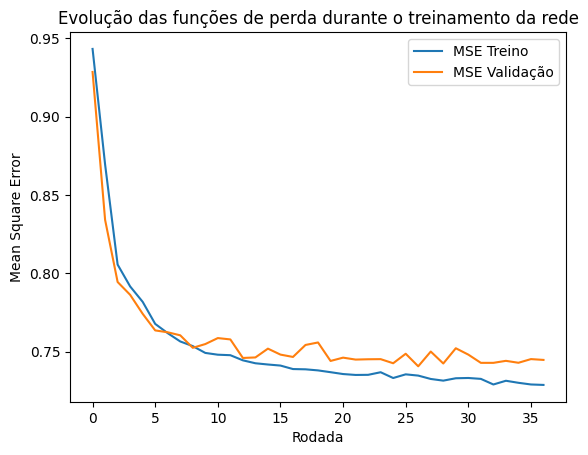

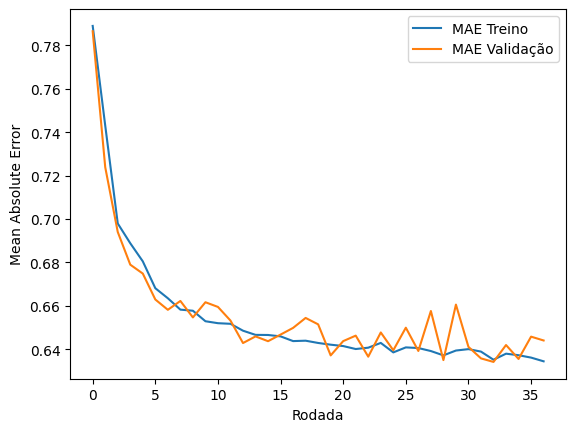

In [29]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure()
plt.title("Evolução das funções de perda durante o treinamento da rede")
plt.xlabel('Rodada')
plt.ylabel('Mean Square Error')
plt.plot(hist['epoch'], hist['mse'], label='MSE Treino')
plt.plot(hist['epoch'], hist['val_mse'], label = 'MSE Validação')
plt.legend()

plt.figure()
plt.xlabel('Rodada')
plt.ylabel('Mean Absolute Error')
plt.plot(hist['epoch'], hist['mae'], label='MAE Treino')
plt.plot(hist['epoch'], hist['val_mae'], label = 'MAE Validação')
plt.legend()

plt.show()

## Prevendo a amostra de teste

### Ajustando a base de teste

In [30]:
x_t = pd.DataFrame(test[0])
x_t.head()

,0
0,"[0.0, 0.0, 9.1552734375e-05, 0.000213623046875..."
7,"[0.0, 9.1552734375e-05, 0.000213623046875, 9.1..."
16,"[0.0, 0.002166748046875, 0.00341796875, -0.002..."
21,"[0.0, 0.0, 0.0, 0.0, 3.0517578125e-05, 6.10351..."
24,"[0.0, 0.0, 0.0, 3.0517578125e-05, 6.103515625e..."


In [31]:
x_t = np.array(x_t[0].values.tolist())
x_t[0]

array([ 0.00000000e+00,  0.00000000e+00,  9.15527344e-05, ...,
       -1.22070312e-04, -6.10351562e-05, -3.05175781e-05])

In [32]:
len(x_t[0])

64000

In [33]:
y_t = test.drop(columns=[0])
y_t.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,76.024,0.969,0.893,1.602,0.989,0.689,0.000,0.937,0.437,0.440,...,2.902,0.000,0.945,0.567,1.153,0.465,0.067,0.111,0.574,0.435
7,2433.588,0.691,0.902,0.000,0.673,0.218,1.344,0.851,0.191,0.000,...,1.463,0.000,0.812,0.666,0.000,0.843,0.489,0.146,0.122,0.215
16,2984.725,0.822,0.163,3.391,0.926,0.194,1.791,0.780,0.338,0.000,...,0.383,3.689,0.477,0.361,0.240,0.717,0.024,0.073,0.252,0.770
21,51.535,0.535,0.175,0.000,0.554,0.438,2.210,0.787,0.728,0.000,...,6.704,0.000,0.993,6.845,4.543,0.825,0.350,0.419,0.457,0.703
24,42.791,0.961,0.636,0.000,0.751,4.037,4.272,0.736,1.109,4.656,...,1.397,0.000,0.781,0.153,4.310,0.718,0.210,0.539,0.759,0.087


### Chamando o modelo para predição

In [34]:
y_pred_norm = model.predict(x_t)

40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step


In [35]:
y_pred = scaler_y.inverse_transform(y_pred_norm)

In [36]:
y_pred = pd.DataFrame(y_pred)
y_pred.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,218.344299,0.674128,1.871514,1.773752,0.705049,1.816483,1.810954,0.662781,1.748305,2.057326,...,1.917020,1.867059,0.686536,1.723237,2.066281,0.668947,0.060912,0.175801,0.593965,0.440679
1,2867.314453,0.648768,0.401898,1.056380,0.689202,0.093731,1.165884,0.651678,0.542543,0.808743,...,0.324614,0.889900,0.667579,0.555944,0.405889,0.702467,0.491534,0.126806,0.180477,0.242442
2,2940.464844,0.698064,0.702638,0.867433,0.702098,0.699852,0.945819,0.675670,0.601159,0.862605,...,0.719355,1.014375,0.719532,0.444988,0.902552,0.691789,0.093438,0.138326,0.359399,0.632015
3,306.068115,0.672992,1.609143,1.951539,0.663359,1.804721,1.772813,0.671154,1.834075,1.808820,...,1.841341,2.059187,0.662862,1.688388,2.026385,0.693413,0.344777,0.401168,0.473704,0.671438
4,180.688904,0.687171,2.141869,2.350289,0.679855,1.974522,1.705303,0.685134,1.715954,1.830434,...,1.558875,1.702423,0.679347,1.710418,2.035979,0.686515,0.211687,0.504227,0.733264,0.131158


### Calculando erro de teste

In [37]:
mse = tf.keras.losses.MSE(y_t, y_pred).numpy().mean()
mae = tf.keras.losses.MAE(y_t, y_pred).numpy().mean()
rmse = np.sqrt(mse)

In [38]:
print(f"RMSE Test: {rmse}")
print(f"MSE Test: {mse}")
print(f"MAE Test: {mae}")

RMSE Test: 44.948081970214844
MSE Test: 2020.3299560546875
MAE Test: 8.126298904418945


### Salvando o modelo

In [39]:
model.save('model_conv_1_sec_v1_0.keras')

### Salvando o scaler

In [40]:
# Salvando o scaller_y
import joblib
joblib.dump(scaler_y, 'scaler_y_conv_1_sec_v1_0.save')

['scaler_y_conv_1_sec_v1_0.save']